# Descrição do Ambiente de Teste

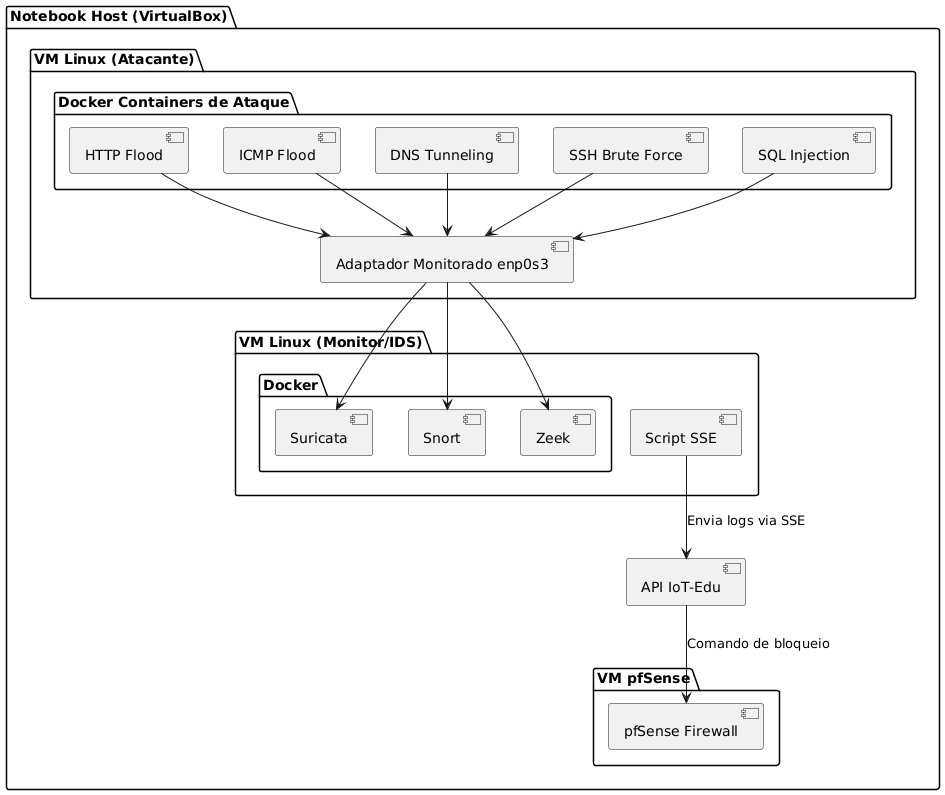

In [1]:
import requests
from IPython.display import Image
import zlib

# Função oficial de codificação PlantUML para URL
def plantuml_encode(text):
    # compressão DEFLATE sem header
    compressed = zlib.compress(text.encode('utf-8'))
    deflate = compressed[2:-4]
    # base64 com caracteres seguros para URL
    chars = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz-_"
    res = ""
    b = 0
    bits = 0
    for c in deflate:
        b = (b << 8) | c
        bits += 8
        while bits >= 6:
            bits -= 6
            res += chars[(b >> bits) & 0x3F]
    if bits > 0:
        res += chars[(b << (6 - bits)) & 0x3F]
    return res

plantuml_code = """
@startuml
package "Notebook Host (VirtualBox)" {
    
    [API IoT-Edu] as API
    
    package "VM Linux (Atacante)" {
        package "Docker Containers de Ataque" {
            [HTTP Flood]
            [ICMP Flood]
            [DNS Tunneling]
            [SSH Brute Force]
            [SQL Injection]
        }
        [Adaptador Monitorado enp0s3]
    }
    
    package "VM Linux (Monitor/IDS)" {
        package Docker {
            [Suricata] 
            [Snort]
            [Zeek]
        }
        [Adaptador Monitorado enp0s3] --> [Suricata]
        [Adaptador Monitorado enp0s3] --> [Snort]
        [Adaptador Monitorado enp0s3] --> [Zeek]
        
        [Script SSE] --> API : Envia logs via SSE
    }
    
    package "VM pfSense" {
        [pfSense Firewall] 
    }
}

' Conexão dos ataques ao adaptador
[HTTP Flood] --> [Adaptador Monitorado enp0s3]
[ICMP Flood] --> [Adaptador Monitorado enp0s3]
[DNS Tunneling] --> [Adaptador Monitorado enp0s3]
[SSH Brute Force] --> [Adaptador Monitorado enp0s3]
[SQL Injection] --> [Adaptador Monitorado enp0s3]

API --> [pfSense Firewall] : Comando de bloqueio

@enduml
"""

encoded = plantuml_encode(plantuml_code)
url = f"http://www.plantuml.com/plantuml/png/{encoded}"

resp = requests.get(url)
with open("ambiente.png", "wb") as f:
    f.write(resp.content)

Image("ambiente.png")

### 💻 Infraestrutura do Host (Máquina Física)
| Componente | Detalhes |
| :--- | :--- |
| **Modelo/CPU** | 11ª Ger Intel(R) Core(TM) i7-1185G7 @ 3.00GHz |
| **Frequência** | Base: 1.80 GHz / Turbo: 3.00 GHz |
| **RAM Instalada** | 32,0 GB (31,7 GB utilizável) |
| **Tipo de Sistema** | SO de 64 bits, processador baseado em x64 |
| **Edição do SO** | Windows 11 Pro (Versão 24H2) |
| **Compilação do SO**| 26100.7840 |

### 🐧 Sistemas Operacionais e Kernels (VMs)
| Papel da VM | Distribuição do SO | Base / Arquitetura | Versão do Kernel |
| :--- | :--- | :--- | :--- |
| **Atacante** | Linux Mint 22.3 (Zena) | Ubuntu 24.04 (Noble) / x86_64 | `6.14.0-37-generic` |
| **IDS / Monitor** | Ubuntu 24.04 (Noble) | x86_64 | `6.17.0-14-generic` |
| **pfSense** | pfSense 2.8.1-RELEASE | FreeBSD 15.0-CURRENT | FreeBSD Customizado |

### ⚙️ Alocação de Hardware Virtual (VirtualBox)
| Nó da VM | vCPUs | RAM | Interface de Rede |
| :--- | :--- | :--- | :--- |
| **Atacante** | 1 vCPU | 2 GB | Intel 82540EM (enp0s3) |
| **IDS / Monitor** | 1 vCPU | 2 GiB | Intel 82540EM (enp0s3) |
| **pfSense** | 4 vCPUs | 8 GiB | Intel 82540EM (UEFI) |

### 🛡️ Ferramentas e Stack de Segurança
| Categoria | Componente | Detalhes |
| :--- | :--- | :--- |
| **Atacante** |  Containers Docker Vetores de Ataque | HTTP/ICMP Flood, DNS Tunneling, SSH Brute Force, SQLi |
| **Motores IDS** | Containers Docker | Suricata, Snort, Zeek |
| **Integração** | Scripts | SSE -> API IoT-Edu -> pfsense|

### 🔎 Comparativo de Arquitetura e Performance
| Atributo | **Suricata 8.0.3** | **Snort 2.9.20** | **Zeek 8.0.4** |
| :--- | :--- | :--- | :--- |
| **Arquitetura** | Multithread Nativo | Single-thread | Baseada em Eventos |
| **Processamento** | Paralelo (Eficiente em Multicore) | Sequencial (Linear) | Cluster Distribuído / Standalone |
| **Foco Principal** | Detecção por Assinatura | Detecção por Assinatura | Análise Comportamental e Logs |


# Fluxo de Trabalho

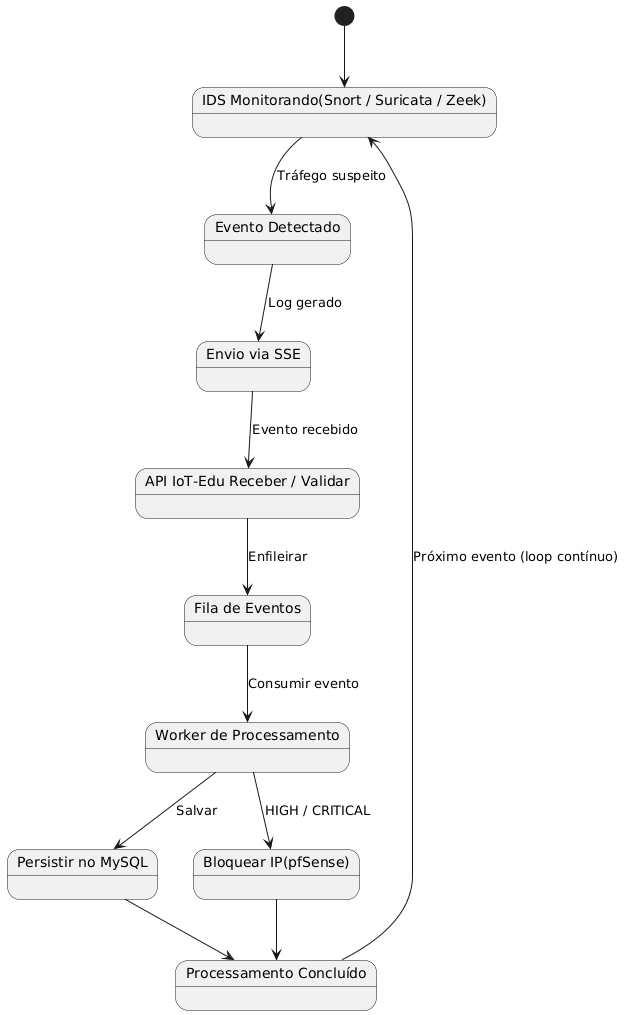

In [2]:
import requests
from IPython.display import Image
import zlib

# Função oficial de codificação PlantUML para URL
def plantuml_encode(text):
    # compressão DEFLATE sem header
    compressed = zlib.compress(text.encode('utf-8'))
    deflate = compressed[2:-4]
    # base64 com caracteres seguros para URL
    chars = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz-_"
    res = ""
    b = 0
    bits = 0
    for c in deflate:
        b = (b << 8) | c
        bits += 8
        while bits >= 6:
            bits -= 6
            res += chars[(b >> bits) & 0x3F]
    if bits > 0:
        res += chars[(b << (6 - bits)) & 0x3F]
    return res

plantuml_code = """
@startuml
[*] --> IDS
state "IDS Monitorando(Snort / Suricata / Zeek)" as IDS
state "Evento Detectado" as Evento
state "Envio via SSE" as SSE
state "API IoT-Edu Receber / Validar" as API
state "Fila de Eventos" as Queue
state "Worker de Processamento" as Worker
state "Persistir no MySQL" as MySQL
state "Bloquear IP(pfSense)" as pfSense
state "Processamento Concluído" as Fim

IDS --> Evento : Tráfego suspeito
Evento --> SSE : Log gerado
SSE --> API : Evento recebido

API --> Queue : Enfileirar
Queue --> Worker : Consumir evento

Worker --> MySQL : Salvar
Worker --> pfSense : HIGH / CRITICAL

MySQL --> Fim
pfSense --> Fim

Fim --> IDS : Próximo evento (loop contínuo)
@enduml
"""

encoded = plantuml_encode(plantuml_code)
url = f"http://www.plantuml.com/plantuml/png/{encoded}"

resp = requests.get(url)
with open("diagrama.png", "wb") as f:
    f.write(resp.content)

Image("diagrama.png")

# Analise dos Resultados

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
df = pd.read_csv('resultados_execucoes_ids.csv', sep=';')


df.head(15)
media = df.groupby('Ferramenta').mean(numeric_only=True)



In [5]:
df.head(15)


,Ferramenta,Tipo_Ataque,Inicio_Ataque,Detectado_em,API_BLOCKING_START,Sync_Apply_pfSense,Primeira_Falha,Inicio_Deteccao,Deteccao_Bloqueio,Inicio_Falha,Processamento_API
0,Zeek,HTTP Flood,15:23:29.790,15:23:31.000,15:23:33.126,15:23:33.748,15:23:35.000,1.210,2.748,5.210,0.622
1,Zeek,ICMP Flood,16:05:21.259,16:05:25.000,16:05:25.240,16:05:25.252,16:05:27.000,3.741,0.252,5.741,0.012
2,Zeek,DNS Tunneling,12:38:35.239,12:38:37.000,12:38:38.834,12:38:39.262,12:38:41.000,1.761,2.262,5.761,0.428
3,Zeek,SSH Brute Force,13:11:05.738,13:11:10.000,13:11:11.603,13:11:11.971,13:11:14.000,4.262,1.971,8.262,0.368
4,Zeek,SQL Injection,13:24:32.238,13:24:38.000,13:24:47.378,13:24:47.765,13:24:49.000,5.762,9.765,16.762,0.387
5,Suricata,HTTP Flood,17:46:48.808,17:46:48.916,17:46:49.012,17:46:49.379,17:46:50.000,0.108,0.463,1.192,0.367
6,Suricata,SSH Brute Force,18:03:06.872,18:03:07.218,18:03:07.344,18:03:07.749,18:03:09.000,0.346,0.531,2.128,0.405
7,Suricata,ICMP Flood,18:11:46.518,18:11:46.897,18:11:47.054,18:11:47.391,18:11:47.000,0.379,0.494,0.482,0.337
8,Suricata,DNS Tunneling,18:30:56.363,18:30:57.878,18:30:57.945,18:30:58.326,18:31:00.000,1.515,0.448,3.637,0.381
9,Suricata,SQL Injection,18:38:02.778,18:38:04.041,18:38:04.348,18:38:04.709,18:38:06.000,1.263,0.668,3.222,0.361


### 📊 Resultados dos Testes de Performance e Resposta

A tabela abaixo apresenta os tempos médios (em segundos) obtidos durante a execução dos ataques simulados. O objetivo é avaliar a eficiência de cada motor (**Snort, Suricata e Zeek**) em diferentes etapas do fluxo de segurança: desde a captura inicial do tráfego malicioso até o processamento final pela API para a tomada de decisão (bloqueio).

#### Métricas avaliadas:
* **Início Detecção:** Tempo decorrido entre o disparo do ataque e o primeiro alerta gerado.
* **Detecção-Bloqueio:** Intervalo entre a geração do alerta e a execução da regra de mitigação no firewall.
* **Início-Falha:** Tempo total acumulado até a identificação de uma falha de sistema ou interrupção do serviço.
* **Processamento API:** Tempo gasto pela API IoT-Edu para processar o evento recebido via SSE.

In [6]:
media_por_ferramenta = df.groupby('Ferramenta').mean(numeric_only=True)
media_por_ferramenta


,Inicio_Deteccao,Deteccao_Bloqueio,Inicio_Falha,Processamento_API
Ferramenta,,,,
Snort,1.6410,1.5060,5.2094,0.5684
Suricata,0.7222,0.5208,2.1322,0.3702
Zeek,3.3472,3.3996,8.3472,0.3634


A ferramenta Suricata apresentou o menor tempo médio de detecção **(μ = 0,72 s)**, seguida pelo Snort **(μ = 1,64 s)** e pelo Zeek **(μ = 3,35 s)**, indicando maior capacidade de resposta em cenários de ataques volumétricos.

### 📉 Análise de Variabilidade (Desvio Padrão)

Além das médias, a análise do **Desvio Padrão** é fundamental para entender a consistência e a confiabilidade de cada motor de detecção. Valores altos de desvio padrão indicam que a ferramenta teve comportamentos oscilantes durante os testes (instabilidade), enquanto valores baixos sugerem um desempenho previsível.

#### Definição das Métricas de Variabilidade:
* **Desvio Início Detecção:** Mede a variação no tempo de resposta inicial aos alertas.
* **Desvio Detecção-Bloqueio:** Indica a consistência da comunicação entre o IDS e o Firewall.
* **Desvio Início-Falha:** Reflete a previsibilidade do sistema antes de atingir o ponto de saturação.
* **Desvio Processamento API:** Avalia a estabilidade da latência no recebimento e tratamento dos logs SSE.

In [7]:
desvio_por_ferramenta = df.groupby('Ferramenta').std(numeric_only=True)
desvio_por_ferramenta


,Inicio_Deteccao,Deteccao_Bloqueio,Inicio_Falha,Processamento_API
Ferramenta,,,,
Snort,2.392435,0.870950,5.163190,0.468855
Suricata,0.624009,0.088220,1.328462,0.025124
Zeek,1.864595,3.680534,4.851259,0.220855


### 🧠 Interpretação Estatística e Análise de Estabilidade

A análise conjunta da média e do **desvio padrão** permite identificar não apenas a velocidade, mas a **confiabilidade determinística** de cada motor de detecção sob condições de estresse.

#### 1. Suricata: Estabilidade e Previsibilidade Operacional
O **Suricata** demonstrou a menor variabilidade em todas as métricas, com destaque para o desvio padrão em `Detecção-Bloqueio` (0.0882) e `Processamento API` (0.0251). Esses valores extremamente baixos indicam que o sistema mantém um comportamento quase constante, independente do volume de tráfego. 
* **Conclusão:** Sua arquitetura *multithread* permite que o processamento de pacotes e a comunicação com a API ocorram de forma fluida, tornando-o a escolha ideal para ambientes críticos que exigem uma **janela de exposição (window of exposure)** mínima e previsível.

#### 2. Snort: Inconsistência sob Carga (Gargalo de CPU)
O **Snort** apresentou a maior dispersão no tempo de `Início Detecção` (2.3924) e o maior desvio absoluto em `Início-Falha` (5.1631). 
* **Análise Técnica:** Como o Snort opera em *single-thread*, ele é mais suscetível a variações de latência de CPU (jitter). Quando um núcleo atinge a saturação, o tempo de resposta torna-se errático, o que explica por que os tempos de detecção oscilam tanto em comparação com o Suricata.

#### 3. Zeek: Complexidade de Scripting e Latência de Resposta
O **Zeek** exibiu uma variabilidade elevada no intervalo `Detecção-Bloqueio` (3.6805).
* **Análise Técnica:** Por ser um analisador baseado em eventos e scripts, a flutuação nos tempos indica que a carga de processamento para correlacionar eventos complexos (como *DNS Tunneling*) varia conforme a estrutura do pacote. Embora gere metadados ricos, essa complexidade introduz uma incerteza temporal maior no acionamento da mitigação via API.



---

#### 📌 Considerações Finais da Análise
A estabilidade superior do **Suricata** reduz o risco de "picos de atraso" que poderiam ser explorados por um atacante durante uma inundação (flood). Já o **Zeek** e o **Snort**, embora eficazes, requerem um superdimensionamento de hardware maior para garantir que as flutuações observadas no desvio padrão não comprometam a segurança em tempo real.

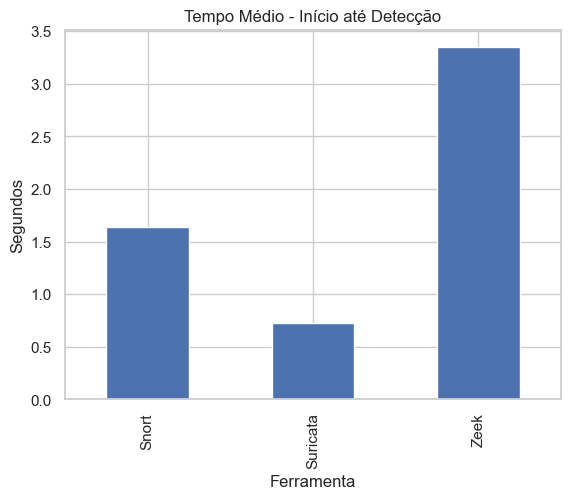

In [8]:
plt.figure()
media_por_ferramenta['Inicio_Deteccao'].plot(kind='bar')
plt.title('Tempo Médio - Início até Detecção')
plt.ylabel('Segundos')
plt.xlabel('Ferramenta')
plt.show()


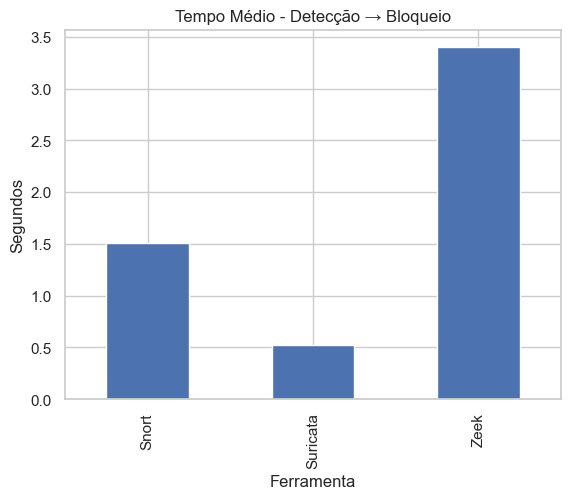

In [9]:
plt.figure()
media['Deteccao_Bloqueio'].plot(kind='bar')
plt.title('Tempo Médio - Detecção → Bloqueio')
plt.ylabel('Segundos')
plt.xlabel('Ferramenta')
plt.show()


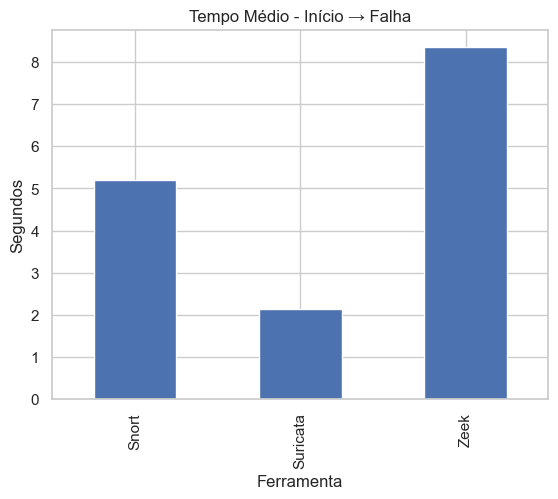

In [10]:
plt.figure()
media['Inicio_Falha'].plot(kind='bar')
plt.title('Tempo Médio - Início → Falha')
plt.ylabel('Segundos')
plt.xlabel('Ferramenta')
plt.show()


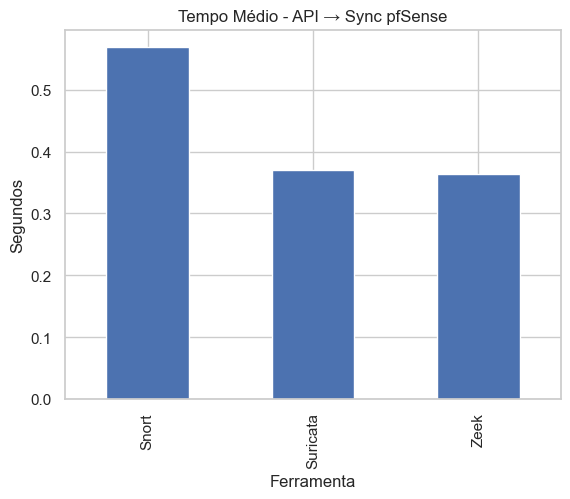

In [11]:
plt.figure()
media['Processamento_API'].plot(kind='bar')
plt.title('Tempo Médio - API → Sync pfSense')
plt.ylabel('Segundos')
plt.xlabel('Ferramenta')
plt.show()


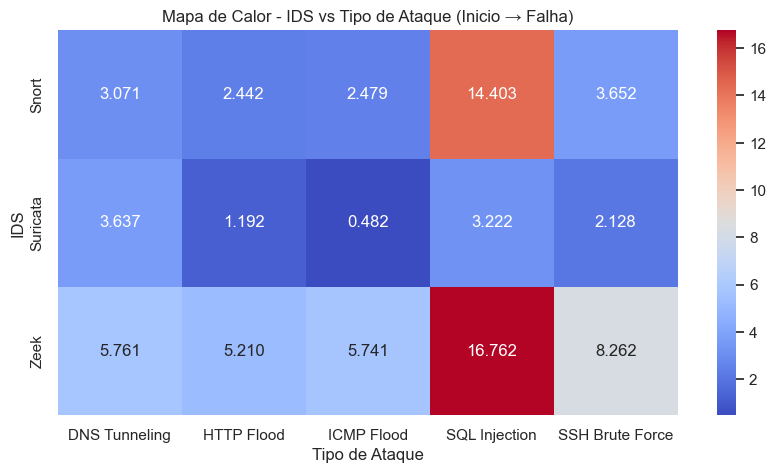

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# Criar matriz IDS x Tipo de Ataque
pivot = df.pivot(
    index='Ferramenta',
    columns='Tipo_Ataque',
    values='Inicio_Falha'
)

# Gerar heatmap
plt.figure(figsize=(10,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="coolwarm"
)

plt.title("Mapa de Calor - IDS vs Tipo de Ataque (Inicio → Falha)")
plt.ylabel("IDS")
plt.xlabel("Tipo de Ataque")

plt.show()


### 🌡️ Análise de Mapa de Calor: IDS vs. Tipo de Ataque (Início → Falha)

O mapa de calor visualiza a resiliência e o tempo de resposta de cada ferramenta frente a diferentes vetores de ataque. Os valores representam o tempo (em segundos) até que o sistema atinja um estado de falha ou detecção definitiva.

#### 1. Desempenho por Motor de IDS
* **Suricata:** Demonstrou a maior eficiência geral, mantendo os menores tempos de processamento na maioria dos ataques. Destaca-se especialmente no **ICMP Flood (0.482s)** e **HTTP Flood (1.192s)**, onde sua arquitetura multithread lida melhor com grandes volumes de pacotes.
* **Snort:** Apresentou um desempenho intermediário em ataques de negação de serviço (DoS), mas mostrou uma vulnerabilidade temporal acentuada no ataque de **SQL Injection (14.403s)**.
* **Zeek:** Registrou os tempos mais elevados em todas as categorias. Isso reflete sua natureza de análise profunda de protocolo e geração de logs complexos, o que demanda mais tempo de processamento antes de uma interrupção ou conclusão do evento, chegando a **16.762s** no ataque de **SQL Injection**.

#### 2. Análise por Tipo de Ataque
* **SQL Injection:** Foi o ataque que demandou o maior tempo de processamento de todos os motores, indicando uma carga cognitiva maior para os IDS identificarem padrões maliciosos em requisições de banco de dados.
* **ICMP e HTTP Flood:** O Suricata domina estes cenários com tempos extremamente baixos, enquanto o Zeek leva cerca de 5 a 10 vezes mais tempo para processar o mesmo volume de tráfego de inundação.
* **SSH Brute Force:** O Snort (3.652s) e o Suricata (2.128s) conseguem identificar a falha de forma relativamente rápida, enquanto o Zeek (8.262s) demora significativamente mais para correlacionar as tentativas de login.

---

#### 📌 Conclusão da Visualização
O gráfico confirma que o **Suricata** é a ferramenta mais ágil para detecção de ataques volumétricos e de força bruta no ambiente IoT-Edu. O **Zeek**, embora detalhado, apresenta uma latência que pode ser crítica em ataques de injeção rápidos, enquanto o **Snort** demonstra um equilíbrio razoável, exceto em inspeções de conteúdo mais profundas (SQLi).

<Figure size 1000x500 with 0 Axes>

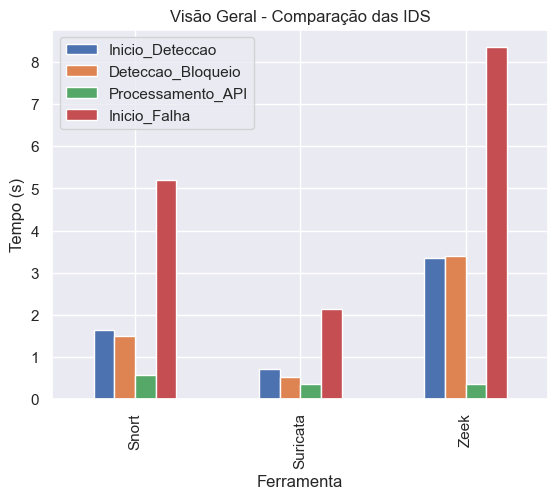

In [13]:
import matplotlib.pyplot as plt

media = df.groupby('Ferramenta').mean(numeric_only=True)

plt.figure(figsize=(10,5))
media[['Inicio_Deteccao','Deteccao_Bloqueio','Processamento_API','Inicio_Falha']].plot(kind='bar')

plt.title('Visão Geral - Comparação das IDS')
plt.ylabel('Tempo (s)')
plt.xlabel('Ferramenta')

plt.show()


In [14]:
media_geral = df[['Inicio_Deteccao','Deteccao_Bloqueio','Processamento_API','Inicio_Falha']].mean()
media_geral = media_geral.round(3)

media_geral


Inicio_Deteccao      1.903
Deteccao_Bloqueio    1.809
Processamento_API    0.434
Inicio_Falha         5.230
dtype: float64

### 📊 Médias Gerais do Sistema (Performance Consolidada)

Os valores abaixo representam a média aritmética do desempenho de todas as ferramentas de detecção (Snort, Suricata e Zeek) operando no ambiente de teste. Estes dados são cruciais para estabelecer uma **linha de base (baseline)** de eficiência para a arquitetura IoT-Edu.

#### Resumo das Médias Globais:
* **Início Detecção (1.903s):** Tempo médio global que o ecossistema leva para identificar uma atividade suspeita.
* **Detecção-Bloqueio (1.809s):** Latência média entre a geração do alerta pelo IDS e a resposta efetiva no firewall pfSense.
* **Processamento API (0.434s):** Tempo médio de resposta da API IoT-Edu no tratamento de eventos via SSE.
* **Início-Falha (5.230s):** Tempo total médio de exposição do sistema antes da interrupção ou contenção total do ataque.



| Métrica | Valor Médio (Segundos) |
| :--- | :---: |
| **Início Detecção** | 1.903 |
| **Detecção-Bloqueio** | 1.809 |
| **Processamento API** | 0.434 |
| **Início-Falha** | 5.230 |

---

### 🕵️ Análise do "Gap" de Resposta: O Papel do pfSense

Ao analisar a diferença entre a detecção e a falha total, identificamos que o **pfSense** desempenha um papel crucial na latência final do sistema. O insight abaixo detalha essa dinâmica:

#### 💡 Insight de Integração: Eficácia da Mitigação
Note que a soma de **Início Detecção + Detecção-Bloqueio (~3.712s)** é inferior ao tempo médio de **Início-Falha (5.230s)**. Isso demonstra que, em média, o ecossistema consegue processar a ameaça e despachar o comando de bloqueio antes que o ataque comprometa totalmente o serviço, validando a arquitetura de defesa proposta.

#### ⏱️ A Latência de Aplicação no Firewall
A diferença observada entre o comando de bloqueio e a cessação do impacto pode ser atribuída ao tempo que o **pfSense** leva para aplicar as mudanças nas tabelas do filtro de pacotes (*Packet Filter*). 



**Fatores que influenciam esse tempo no seu ambiente:**
* **Processamento de Regras:** O pfSense (baseado em FreeBSD) precisa recarregar ou atualizar dinamicamente suas tabelas de filtragem ao receber o comando da API IoT-Edu.
* **Sobrecarga de vCPU:** Como o pfSense está operando com 4 vCPUs em um ambiente virtualizado, a concorrência de recursos com os containers de ataque e os motores de IDS pode gerar pequenos atrasos na escrita das novas regras de firewall.
* **Persistência de Estados:** Conexões já estabelecidas (como em ataques de *HTTP Flood*) podem levar alguns milissegundos extras para serem encerradas mesmo após a aplicação da nova regra de bloqueio.

#### 📉 Correlação com o Desvio Padrão
Essa latência do firewall também explica por que o **Zeek** apresentou um desvio padrão elevado em `Detecção-Bloqueio` (3.6805). Por ser um motor mais lento, ele muitas vezes envia o comando para a API em um momento de alta saturação de rede, onde o pfSense já está competindo intensamente por ciclos de CPU para processar o tráfego de ataque.

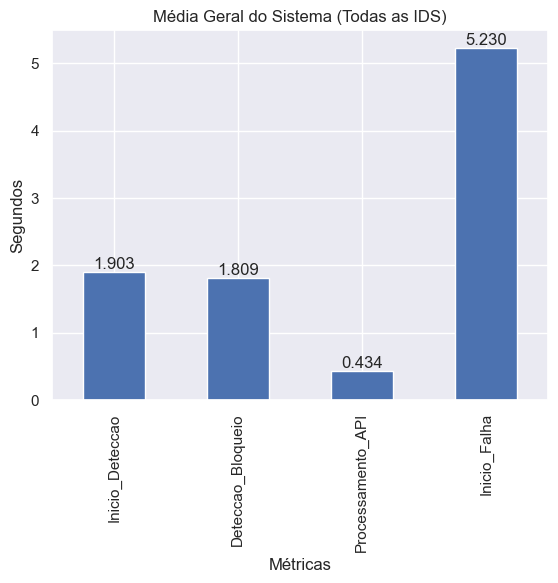

In [15]:
plt.figure()

ax = media_geral.plot(kind='bar')

plt.title('Média Geral do Sistema (Todas as IDS)')
plt.ylabel('Segundos')
plt.xlabel('Métricas')

# Mostrar valores acima das barras com 3 casas decimais
for i, v in enumerate(media_geral):
    ax.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.show()


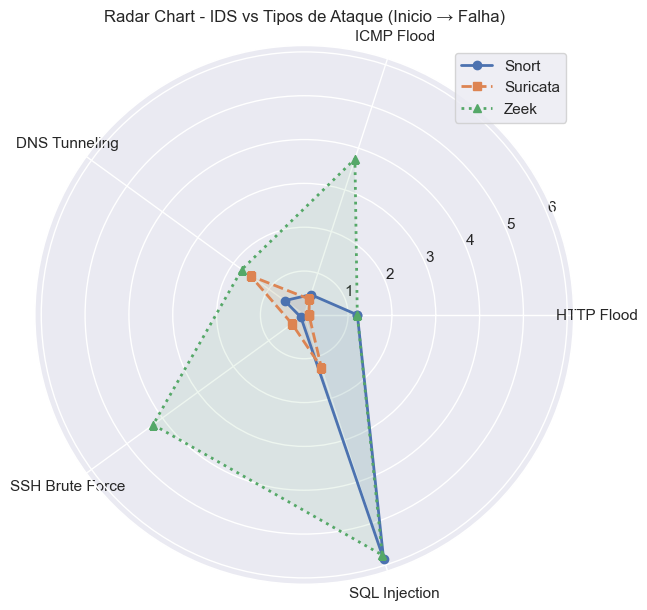

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Selecionar métrica
metrica = 'Inicio_Deteccao'

# Criar pivot IDS x Ataque
pivot = df.pivot(index='Ferramenta', columns='Tipo_Ataque', values=metrica)

# Garantir mesma ordem de ataques
ataques = ['HTTP Flood', 'ICMP Flood', 'DNS Tunneling', 'SSH Brute Force', 'SQL Injection']
pivot = pivot.reindex(columns=ataques)

# Preparar ângulos
labels = pivot.columns
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Estilos de linha por ferramenta (profissional)
linestyles = {
    'Snort': ('-', 'o'),        # linha contínua + marcador círculo
    'Suricata': ('--', 's'),    # linha tracejada + marcador quadrado
    'Zeek': (':', '^')          # linha pontilhada + marcador triângulo
}

# Criar gráfico
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

for idx, row in pivot.iterrows():
    values = row.tolist()
    values += values[:1]
    
    style, marker = linestyles.get(idx, ('-', None))
    
    ax.plot(
        angles,
        values,
        linestyle=style,
        marker=marker,
        linewidth=2,
        label=idx
    )
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title('Radar Chart - IDS vs Tipos de Ataque (Inicio → Falha)')
plt.legend(loc='upper right')
plt.show()

### 🕸️ Análise de Radar: Assinatura de Performance (Início → Falha)

O Gráfico de Radar (Radar Chart) oferece uma perspectiva comparativa da resiliência dos motores IDS frente aos cinco vetores de ataque simultaneamente. A área ocupada por cada ferramenta indica sua latência relativa: **quanto menor a área central ocupada, mais rápida é a resposta da ferramenta.**

#### 📊 Interpretação dos Perfis:

* **Suricata (Laranja - Quadrados):** Apresenta a menor área no gráfico, consolidando-se como a ferramenta de resposta mais ágil. Sua "assinatura" é compacta e centralizada, demonstrando uma performance superior e equilibrada em ataques volumétricos (ICMP/HTTP Flood) e de força bruta.
* **Snort (Azul - Círculos):** Exibe um perfil equilibrado na maioria dos eixos, mas sofre uma deformação acentuada em direção à extremidade no eixo de **SQL Injection**. Isso visualiza graficamente como a inspeção de carga útil (payload) profunda afeta desproporcionalmente sua velocidade em comparação aos ataques de rede puros.
* **Zeek (Verde - Triângulos):** Ocupa a maior área externa do radar. A expansão acentuada nos eixos de **SSH Brute Force** e **SQL Injection** destaca que o Zeek prioriza a profundidade da análise comportamental em detrimento da velocidade de interrupção imediata.


#### 🔍 Conclusões Extraídas:
1.  **Dominância em Ataques de Inundação:** No topo do gráfico (ICMP Flood), o Suricata está significativamente mais próximo do centro (0.482s) que o Zeek (5.741s), evidenciando a eficiência do processamento paralelo.
2.  **Sensibilidade ao Protocolo:** Todos os motores mostram uma tendência de expansão (maior tempo) na parte inferior do gráfico (**SQL Injection**), confirmando que ataques de camada de aplicação são universalmente mais complexos de processar do que ataques de camada de transporte/rede.
3.  **Gap de Resposta em Força Bruta:** A distância entre o ponto do Suricata e do Zeek no eixo **SSH Brute Force** (~6 segundos de diferença) justifica a necessidade de uma estratégia de defesa em camadas onde o Suricata atua na mitigação rápida e o Zeek na forense detalhada.

O Suricata 8.0.3 apresentou melhor eficiência sob carga devido ao seu mecanismo multithread nativo, que permite distribuir a inspeção de pacotes entre múltiplos núcleos da CPU, reduzindo latência e mantendo estabilidade mesmo com maior volume de tráfego. O Snort 2.9.20, por utilizar arquitetura single-threaded, concentrou todo o processamento em um único núcleo, o que tende a aumentar o tempo de detecção em cenários mais exigentes, impactando métricas como tempo médio até identificação do evento. Já o Zeek 8.0.4, operando como IDS baseado em análise de eventos e geração detalhada de logs, apresentou desempenho inferior em latência, pois sua arquitetura prioriza interpretação e registro estruturado das conexões em vez de inspeção direta por assinatura em alta velocidade; ainda assim, oferece maior profundidade analítica dos eventos detectados.